<a href="https://colab.research.google.com/github/Nandaodevmax/predictive-maintenance-project/blob/main/Manuten%C3%A7%C3%A3o%20e%20Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 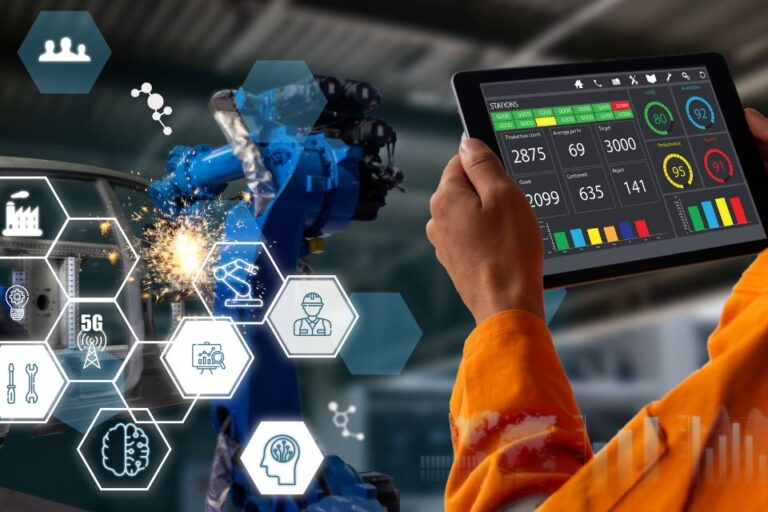Projeto de **Análise** de Dados para Indústria

In [31]:
from google.colab import files
uploaded = files.upload()

Saving Manutencao-preditiva-na-industria-4.0-o-poder-da-IA-e-IoT-no-processo-768x512.jpg to Manutencao-preditiva-na-industria-4.0-o-poder-da-IA-e-IoT-no-processo-768x512 (1).jpg


(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

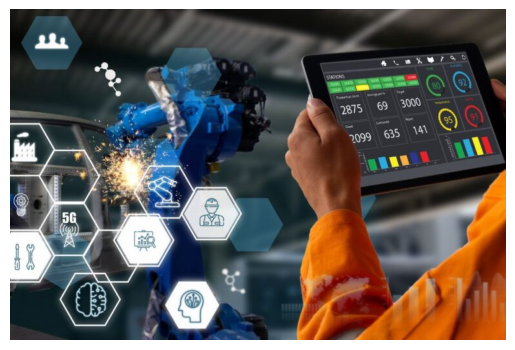

In [48]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('Manutencao-preditiva-na-industria-4.0-o-poder-da-IA-e-IoT-no-processo-768x512.jpg')
plt.imshow(img)
plt.axis('off')

In [32]:
print("Projeto Fernando - Cientista de Dados Industrial iniciado")

Projeto Fernando - Cientista de Dados Industrial iniciado


In [33]:
#criar linhas de falhas:
falhas = ["rolamento", "desalinhamento", "falta de lubrificacao", "sensor com defeito"]
print(falhas)

['rolamento', 'desalinhamento', 'falta de lubrificacao', 'sensor com defeito']


In [34]:
import pandas as pd #simulação de um cenário REAL de indústria
dados = {
    "data":["2026-04-10", "2026-04-11", "2026-04-11", "2026-04-12"],
    "equipamento": ["Esteira 1", "Esterira 2", "Elevador", "Esteira 1"],
    "falha":["rolamento", "desalinhamento", "sensor", "lubrificacao"],
    "tempo_parado_horas":[2, 3.5, 1, 4]

}

df = pd.DataFrame(dados)

df

,data,equipamento,falha,tempo_parado_horas
0,2026-04-10,Esteira 1,rolamento,2.0
1,2026-04-11,Esterira 2,desalinhamento,3.5
2,2026-04-11,Elevador,sensor,1.0
3,2026-04-12,Esteira 1,lubrificacao,4.0


In [35]:
df["tempo_parado_horas"].mean() #tempo médio de parada

np.float64(2.625)

In [36]:
df.groupby("equipamento")["tempo_parado_horas"].sum() #Aqui descobimos qual máquina está dando maior prejuízo

,tempo_parado_horas
equipamento,
Elevador,1.0
Esteira 1,6.0
Esterira 2,3.5


In [37]:
df["falha"].value_counts()#Aqui identificamos qual tipo de falha acontece mais

,count
falha,
rolamento,1
desalinhamento,1
sensor,1
lubrificacao,1


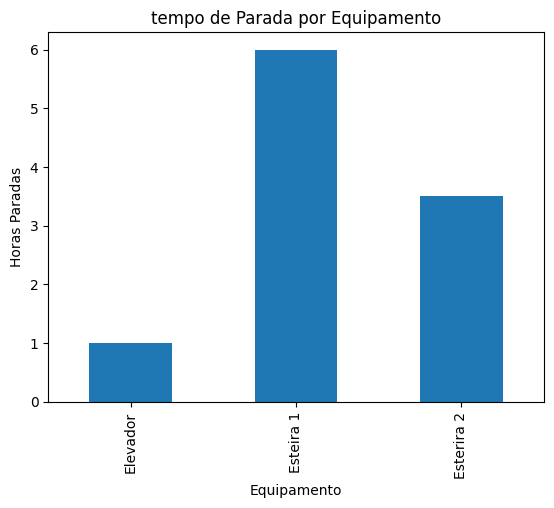

In [38]:
#Visualização - Mostra visualmente qual equipamento dá mais prejuízo
import matplotlib.pyplot as plt

df.groupby("equipamento")["tempo_parado_horas"].sum().plot(kind="bar")

plt.title("tempo de Parada por Equipamento")
plt.xlabel("Equipamento")
plt.ylabel("Horas Paradas")

plt.show()



In [39]:
relatorio = ["A analise indica que a Esteira 1 é o equipamento mais crítico, concentrando maior tempo de parada e maior frequencia de falhas. As ocorrencias relacionadas a rolamentos e lubrificacao sugerem falha no plano de manutencao preventiva. Recomennda-se revisao da periodicidade de lubrificacao, inspecao direcionada em componentes rotativos e, se possivel, implementacao de monitoramento de condicao para antecipar falhas "]
print(relatorio)

['A analise indica que a Esteira 1 é o equipamento mais crítico, concentrando maior tempo de parada e maior frequencia de falhas. As ocorrencias relacionadas a rolamentos e lubrificacao sugerem falha no plano de manutencao preventiva. Recomennda-se revisao da periodicidade de lubrificacao, inspecao direcionada em componentes rotativos e, se possivel, implementacao de monitoramento de condicao para antecipar falhas ']


In [40]:
previsao_falhas = ["Com os dados de temperatura, vibracao e historico de falhas, e possivel construir um modelo preditivo para identificar padroes que antecedem falhas. A partir disso, seria possivel treinar um algoritmo para classificar ou prever a probabilidade de falha de um equipamento com base em variaveis operacionais, permitindo atuacao preventiva antes da quebra "] # Como usaria essas informações para prever falhas

print(previsao_falhas)

['Com os dados de temperatura, vibracao e historico de falhas, e possivel construir um modelo preditivo para identificar padroes que antecedem falhas. A partir disso, seria possivel treinar um algoritmo para classificar ou prever a probabilidade de falha de um equipamento com base em variaveis operacionais, permitindo atuacao preventiva antes da quebra ']


In [41]:
import pandas as pd
dados = {
    "temperatura":[70, 90],
    "vibracao":["baixa", "alta"],
    "falhou":["nao", "sim"]
}

df = pd.DataFrame(dados)

df

,temperatura,vibracao,falhou
0,70,baixa,nao
1,90,alta,sim


In [42]:
import pandas as pd

dados = {
    "temperatura":[70, 85, 90, 60, 95, 80, 100],
    "vibracao":[ "baixa", "media", "alta", "baixa", "alta", "media", "alta"],
    "falhou":[0, 1, 1, 0, 1, 0, 1]

}

df = pd.DataFrame(dados)

df

,temperatura,vibracao,falhou
0,70,baixa,0
1,85,media,1
2,90,alta,1
3,60,baixa,0
4,95,alta,1
5,80,media,0
6,100,alta,1


In [43]:
df["vibracao"] = df["vibracao"].map({
    "baixa": 0,
    "media": 1,
    "alta": 2

})

df

,temperatura,vibracao,falhou
0,70,0,0
1,85,1,1
2,90,2,1
3,60,0,0
4,95,2,1
5,80,1,0
6,100,2,1


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["temperatura", "vibracao"]]
y = df["falhou"]
X_train, X_test, y_train, y_test,  = train_test_split(X, y, test_size=0.3
)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

modelo.score(X_test, y_test)

0.6666666666666666

In [45]:
modelo.predict([[98, 2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [46]:
#Acurácia mostra quantas vezes o modelo acertou Exemplo: Acuracia 1.0 = 100%

In [47]:
#OVERFITTING mostra que o modelo não aprendeu...ele decorou isso acontece pois o dataset é pequeno: poucas linhas ,  pouca variedade, padrão muito facil de identificar
#entao o modelo memoriza.